# Predicting 30-Day Hospital Readmission Risk Among Diabetic Emergency Inpatient Admissions Using Machine Learning

### Clinical Data Science Project

## Clinical Problem

Hospital readmissions within 30 days are a major challenge in healthcare because they can indicate gaps in care coordination, medication management, patient education, or chronic disease management. Patients with diabetes are at increased risk of complications that may lead to repeated hospital visits.

The goal of this project is to develop a machine learning model that identifies patients at higher risk of being readmitted within 30 days after a diabetes-related hospitalization.

## Business Problem

Healthcare organizations need tools that can identify high-risk patients early so care teams can prioritize interventions, improve care management, reduce preventable readmissions, and potentially lower healthcare costs.

This project aims to support population health management by using electronic health record (EHR) data to predict readmission risk and provide insights into factors associated with higher risk.


## Dataset Overview

This project uses the **Diabetes 130-US Hospitals dataset**, which contains inpatient hospital encounter data from patients with diabetes collected from 130 U.S. hospitals.

The dataset includes patient demographic information, clinical measurements, medications, and healthcare utilization features. This study focuses on identifying factors associated with **30-day hospital readmission** among patients with diabetes who experienced emergency inpatient admissions.

### Dataset Information:

- Contains **101,766 inpatient encounters** from patients with diabetes
- Collected from **130 U.S. hospitals**
- Includes demographic, clinical, medication, and healthcare utilization variables
- The prediction outcome is **30-day hospital readmission**
- Used to identify factors associated with increased readmission risk and develop a machine-learning-ready dataset

## Study Objective

The objective of this study is to identify demographic, clinical, and healthcare utilization factors associated with 30-day hospital readmission among patients with diabetes who experienced emergency inpatient admissions. Additionally, this study aims to develop a machine-learning-ready dataset for predictive modeling of readmission risk.

## Research Question

Which demographic, clinical, and healthcare utilization factors are associated with 30-day hospital readmission among diabetic emergency inpatient admissions?

## Project Workflow

This project follows an end-to-end clinical data science workflow:

1. Connect to SQL Server.
2. Extract and load the healthcare data.
3. Understand the dataset and perform data quality assessments.
4. Transform, clean, and preprocess the data; then save the cleaned dataset in both SQL Server and Jupyter Notebook.
5. Extract the diabetes inpatient cohort for analysis.
6. Perform exploratory data analysis (EDA).
7. Analyze clinical and demographic factors associated with 30-day readmission risk.
8. Engineer features for machine learning.
9. Split the data into training and testing sets.
10. Build, train, and evaluate machine learning models.
11. Interpret model results and summarize key findings.
12. Deploy the final predictive model using Streamlit.


## Tools Used

- Python
- SQL Server
- SQL
- Pandas
- NumPy
- Scikit-learn
- Jupyter Notebook
- VS Code
- Tableau Public
- Streamlit
- GitHub

## Import Libraries

In [177]:
import pyodbc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## SQL Database Connection

The diabetes dataset is stored in Microsoft SQL Server. A connection is established using Python to retrieve patient encounter data for analysis.

In [178]:
conn = pyodbc.connect(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=.\\SQLEXPRESS;"
    "DATABASE=diabetes_db;"
    "Trusted_Connection=yes;"
)

# Part 1: Data Extraction and Loading

The diabetes dataset was extracted from SQL Server using an SQL query and loaded into a pandas DataFrame for analysis. The DataFrame served as the primary dataset for subsequent data validation, data cleaning, cohort selection, exploratory data analysis (EDA), feature engineering, visualization, and machine learning model development..

In [179]:
query = "SELECT * FROM dbo.diabetes_data"
df = pd.read_sql(query, conn)

C:\Users\davon\AppData\Local\Temp\ipykernel_1248\2882961085.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


# Part 2: Data Understanding & Preparation

## 2.1 Understanding the Data

The dataset is inspected to verify successful extraction, review its structure, and identify potential data quality issues before cleaning.

In [180]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide_metformin,glipizide_metformin,glimepiride_pioglitazone,metformin_rosiglitazone,metformin_pioglitazone,change,diabetesMed,readmitted
0,12522,48330783,Caucasian,Female,[80-90),?,2,1,4,13,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
1,15738,63555939,Caucasian,Female,[90-100),?,3,3,4,12,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
2,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
3,28236,89869032,AfricanAmerican,Female,[40-50),?,1,1,7,9,...,No,Steady,No,No,No,No,No,No,Yes,>30
4,35754,82637451,Caucasian,Male,[50-60),?,2,1,2,3,...,No,Steady,No,No,No,No,No,No,Yes,>30


In [181]:
df.shape

(101766, 50)

In [182]:
df.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide_metformin', 'glipizide_metformin',
       'glimepiride_pioglitazone', 'metformin_rosiglitazone',
       'metformin_pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

In [184]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  object
 7   discharge_disposition_id  101766 non-null  object
 8   admission_source_id       101766 non-null  object
 9   time_in_hospital          101766 non-null  object
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  object
 13  num_procedures            101766 non-null  object
 14  num_

### Data Understanding Interpretation

- The dataset contains **101,766 hospital encounters** and **50 variables**.
- The target variable is `readmitted`, which represents the patient readmission outcome.
- The dataset includes both numerical and object variables.

## 2.2 Summary Statistics

The following table provides a statistical summary of both numerical and categorical variables, including central tendency, dispersion, and frequency distribution.

In [185]:
df.describe(include="all")

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide_metformin,glipizide_metformin,glimepiride_pioglitazone,metformin_rosiglitazone,metformin_pioglitazone,change,diabetesMed,readmitted
count,1.017660e+05,1.017660e+05,101766,101766,101766,101766,101766,101766,101766,101766,...,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766
unique,NaN,NaN,6,3,10,10,8,26,17,14,...,1,4,4,2,2,2,2,2,2,3
top,NaN,NaN,Caucasian,Female,[70-80),?,1,1,7,3,...,No,No,No,No,No,No,No,No,Yes,NO
freq,NaN,NaN,76099,54708,26068,98569,53990,60234,57494,17756,...,101766,47383,101060,101753,101765,101764,101765,54755,78363,54864
mean,1.652016e+08,5.433040e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,1.026403e+08,3.869636e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.252200e+04,1.350000e+02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,8.496119e+07,2.341322e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,1.523890e+08,4.550514e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,2.302709e+08,8.754595e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Key Observations:

* The target variable **`readmitted` contained three categories** (`NO`, `>30`, and `<30`) and was transformed into a binary classification outcome to predict 30-day readmission.

* Missing values were represented as **"?"**, requiring conversion and handling during the data cleaning process.

* Identifier variables such as **`encounter_id` and `patient_nbr`** were evaluated and excluded from predictive modeling because they do not represent meaningful clinical predictors.

### 2.2 Data Quality Check

This section evaluates the dataset for missing values, duplicate records, unique value counts, and inconsistent data entries to assess data integrity prior to feature engineering and modeling.

In [186]:
df.isna().sum()

encounter_id                0
patient_nbr                 0
race                        0
gender                      0
age                         0
weight                      0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
payer_code                  0
medical_specialty           0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
diag_1                      0
diag_2                      0
diag_3                      0
number_diagnoses            0
max_glu_serum               0
A1Cresult                   0
metformin                   0
repaglinide                 0
nateglinide                 0
chlorpropamide              0
glimepiride                 0
acetohexamide               0
glipizide                   0
glyburide                   0
tolbutamide                 0
pioglitazo

In [188]:
df.duplicated().sum()

np.int64(0)

In [189]:
df.nunique()

encounter_id                101766
patient_nbr                  71518
race                             6
gender                           3
age                             10
weight                          10
admission_type_id                8
discharge_disposition_id        26
admission_source_id             17
time_in_hospital                14
payer_code                      18
medical_specialty               73
num_lab_procedures             118
num_procedures                   7
num_medications                 75
number_outpatient               39
number_emergency                33
number_inpatient                21
diag_1                         717
diag_2                         749
diag_3                         790
number_diagnoses                16
max_glu_serum                    4
A1Cresult                        4
metformin                        4
repaglinide                      4
nateglinide                      4
chlorpropamide                   4
glimepiride         

In [190]:
(df=="?").sum()

encounter_id                    0
patient_nbr                     0
race                         2273
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum                   0
A1Cresult                       0
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [233]:
numeric_cols = df.select_dtypes(include="number").columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

encounter_id: 0 outliers
patient_nbr: 247 outliers
age: 852 outliers
time_in_hospital: 2252 outliers
number_lab_procedures: 143 outliers
number_procedures: 4954 outliers
number_medications: 2557 outliers
number_emergency: 11383 outliers
number_inpatient_visits: 7049 outliers
number_diagnoses: 281 outliers


### Data Quality Assessment Summary

The dataset was evaluated for data quality issues before modeling:

- Checked missing values (`NaN` and "?")
- Checked duplicate records
- Reviewed unique values and data types
- Assessed potential outliers using the IQR method

Some numerical variables contained extreme values, but they were considered realistic encounters that may represent patients with higher healthcare utilization or more severe illness. Therefore, no outliers were removed before model development.

## 2.3 Transformation and Standardization

Variables were transformed and standardized to improve data consistency and prepare the dataset for analysis and machine learning. This included handling missing values, converting variables into appropriate formats, creating clinically meaningful categories such as age groups, mapping demographic variables, and renaming features to improve readability and interpretation..

In [191]:
df.rename(columns={
    "A1Cresult": "a1c_result",
    "diabetesMed": "diabetes_medication", "change":"change_medication", "num_lab_procedures":"number_lab_procedures",
    "num_procedures":"number_procedures", "num_medications":"number_medications","number_inpatient":"number_inpatient_visits"
}, inplace=True)

df.columns


Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'number_lab_procedures', 'number_procedures', 'number_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient_visits',
       'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum',
       'a1c_result', 'metformin', 'repaglinide', 'nateglinide',
       'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide',
       'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
       'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton',
       'insulin', 'glyburide_metformin', 'glipizide_metformin',
       'glimepiride_pioglitazone', 'metformin_rosiglitazone',
       'metformin_pioglitazone', 'change_medication', 'diabetes_medication',
       'readmitted'],
      dtype='object')

In [192]:
(df == "?").sum()

encounter_id                    0
patient_nbr                     0
race                         2273
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
number_lab_procedures           0
number_procedures               0
number_medications              0
number_outpatient               0
number_emergency                0
number_inpatient_visits         0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum                   0
a1c_result                      0
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [193]:
df.replace(["?", "NA", "N/A"],np.nan,inplace=True)

In [194]:
df.isnull().sum()

encounter_id                    0
patient_nbr                     0
race                         2273
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
number_lab_procedures           0
number_procedures               0
number_medications              0
number_outpatient               0
number_emergency                0
number_inpatient_visits         0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum                   0
a1c_result                      0
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [195]:
race_map = {
    "Caucasian": "White",
    "AfricanAmerican": "Black",
    "asian": "Asian",
    "other": "Other",
    "hispanic": "Hispanic"
}

df["race"] = df["race"].replace(race_map)
df["race"].unique()

array(['White', 'Black', nan, 'Other', 'Asian', 'Hispanic'], dtype=object)

In [196]:
num_cols = [
    "time_in_hospital",
    "number_lab_procedures",
    "number_procedures",
    "number_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient_visits",
    "number_diagnoses"
]

df[num_cols] = df[num_cols].astype(int)
df.dtypes

encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age                         object
weight                      object
admission_type_id           object
discharge_disposition_id    object
admission_source_id         object
time_in_hospital             int64
payer_code                  object
medical_specialty           object
number_lab_procedures        int64
number_procedures            int64
number_medications           int64
number_outpatient            int64
number_emergency             int64
number_inpatient_visits      int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
a1c_result                  object
metformin                   object
repaglinide                 object
nateglinide                 object
chlorpropamide              object
glimepiride         

In [197]:
age_map = {

    "[0-10)": 5,
    "[10-20)": 15,
    "[20-30)": 25,
    "[30-40)": 35,
    "[40-50)": 45,
    "[50-60)": 55,
    "[60-70)": 65,
    "[70-80)": 75,
    "[80-90)": 85,
    "[90-100)": 95
}

df["age"] = df["age"].replace(age_map)
df["age"] = df["age"].astype("int64")
df["age"].value_counts().sort_index()

C:\Users\davon\AppData\Local\Temp\ipykernel_1248\2883879645.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["age"] = df["age"].replace(age_map)


age
5       161
15      691
25     1657
35     3775
45     9685
55    17256
65    22483
75    26068
85    17197
95     2793
Name: count, dtype: int64

In [198]:
cat_cols = [
    "race", "gender",
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id",
    "change_medication",
    "diabetes_medication",
    "readmitted",
    "insulin",
]

cat_cols = [col for col in cat_cols if col in df.columns]

df[cat_cols] = df[cat_cols].astype("category")
df[cat_cols].dtypes

race                        category
gender                      category
admission_type_id           category
discharge_disposition_id    category
admission_source_id         category
change_medication           category
diabetes_medication         category
readmitted                  category
insulin                     category
dtype: object

In [199]:
df["diag_1"] = pd.to_numeric(df["diag_1"], errors="coerce")
df["diag_2"] = pd.to_numeric(df["diag_2"], errors="coerce")
df["diag_3"] = pd.to_numeric(df["diag_3"], errors="coerce")

In [200]:
df[["diag_1", "diag_2", "diag_3"]].dtypes

diag_1    float64
diag_2    float64
diag_3    float64
dtype: object

In [201]:
df["diag_1_group"] = "Other"
df.loc[(df["diag_1"] >= 250) & (df["diag_1"] < 251), "diag_1_group"] = "Diabetes"
df.loc[(df["diag_1"] >= 401) & (df["diag_1"] < 405), "diag_1_group"] = "Hypertension"
df.loc[(df["diag_1"] >= 414) & (df["diag_1"] < 416), "diag_1_group"] = "Heart_Disease"

df["diag_2_group"] = "Other"
df.loc[(df["diag_2"] >= 250) & (df["diag_2"] < 251), "diag_2_group"] = "Diabetes"
df.loc[(df["diag_2"] >= 401) & (df["diag_2"] < 405), "diag_2_group"] = "Hypertension"
df.loc[(df["diag_2"] >= 414) & (df["diag_2"] < 416), "diag_2_group"] = "Heart_Disease"

df["diag_3_group"] = "Other"
df.loc[(df["diag_3"] >= 250) & (df["diag_3"] < 251), "diag_3_group"] = "Diabetes"
df.loc[(df["diag_3"] >= 401) & (df["diag_3"] < 405), "diag_3_group"] = "Hypertension"
df.loc[(df["diag_3"] >= 414) & (df["diag_3"] < 416), "diag_3_group"] = "Heart_Disease"

df[["diag_1_group", "diag_2_group", "diag_3_group"]].head()

,diag_1_group,diag_2_group,diag_3_group
0,Other,Other,Other
1,Other,Other,Other
2,Other,Other,Diabetes
3,Diabetes,Hypertension,Other
4,Heart_Disease,Other,Diabetes


In [202]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 53 columns):
 #   Column                    Non-Null Count   Dtype   
---  ------                    --------------   -----   
 0   encounter_id              101766 non-null  int64   
 1   patient_nbr               101766 non-null  int64   
 2   race                      99493 non-null   category
 3   gender                    101766 non-null  category
 4   age                       101766 non-null  int64   
 5   weight                    3197 non-null    object  
 6   admission_type_id         101766 non-null  category
 7   discharge_disposition_id  101766 non-null  category
 8   admission_source_id       101766 non-null  category
 9   time_in_hospital          101766 non-null  int64   
 10  payer_code                61510 non-null   object  
 11  medical_specialty         51817 non-null   object  
 12  number_lab_procedures     101766 non-null  int64   
 13  number_procedures         101

### Data Standardization Interpretation:

* The dataset has been successfully standardized, improving consistency and interpretability of clinical variables.

* Categorical values were reviewed and standardized, including race categories and missing value representations.

* ICD diagnosis features ('diag_1,' 'diag_2,' and 'diag_3') were transformed into grouped clinical categories to improve model interpretability and reduce feature complexity.

* Column names were standardized to improve readability and maintain consistency throughout the analysis workflow.

* These transformations created a cleaner dataset that is better prepared for data cleaning, exploratory analysis, and machine learning preparation.

* The next steps will focus on validating data quality, addressing remaining missing values, encoding categorical variables, and preparing features for predictive modeling.

# Part 3 :Data Cleaning

Clinical datasets often contain missing values, inconsistent categories, and incorrect data types. Cleaning improves data quality and prepares the dataset for analysis and machine learning.

In [203]:
df[["diag_1", "diag_2", "diag_3"]].isna().sum()

diag_1    1666
diag_2    2894
diag_3    6481
dtype: int64

In [204]:
df["diag_1"] = df["diag_1"].fillna("Unknown")
df["diag_2"] = df["diag_2"].fillna("Unknown")
df["diag_3"] = df["diag_3"].fillna("Unknown")

df[["diag_1", "diag_2", "diag_3"]].isnull().sum()

diag_1    0
diag_2    0
diag_3    0
dtype: int64

In [205]:
df.drop(columns=[
    'weight', 'payer_code', 'medical_specialty', 'number_outpatient',
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
    'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
    'tolazamide', 'examide', 'citoglipton', 'glyburide_metformin',
    'glipizide_metformin', 'glimepiride_pioglitazone',
    'metformin_rosiglitazone', 'metformin_pioglitazone',
    'discharge_disposition_id'
], inplace=True, errors='ignore')

df.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age',
       'admission_type_id', 'admission_source_id', 'time_in_hospital',
       'number_lab_procedures', 'number_procedures', 'number_medications',
       'number_emergency', 'number_inpatient_visits', 'diag_1', 'diag_2',
       'diag_3', 'number_diagnoses', 'max_glu_serum', 'a1c_result', 'insulin',
       'change_medication', 'diabetes_medication', 'readmitted',
       'diag_1_group', 'diag_2_group', 'diag_3_group'],
      dtype='object')

### Data Cleaning Interpretation:

* Removed variables with substantial missing data (e.g., 'weight,' 'payer_code,' and `medical_specialty') because they were unlikely to provide reliable predictive information.

* Removed medication-specific variables due to high sparsity and limited expected contribution to the predictive model.

* Excluded `number_outpatients' to maintain focus on inpatient encounter-related factors.

* Removed `discharge_disposition_id' to reduce potential data leakage risk because it may contain information only available after or during the discharge process.

* These feature reduction steps improved data quality, reduced dataset complexity, and created a more interpretable dataset for exploratory analysis and machine learning.

 # Part 4: Data Validation

After cleaning and standardization, the dataset is validated to confirm that transformations were applied correctly and that the data are ready for analysis.

In [206]:
df.isna().sum()

encounter_id                  0
patient_nbr                   0
race                       2273
gender                        0
age                           0
admission_type_id             0
admission_source_id           0
time_in_hospital              0
number_lab_procedures         0
number_procedures             0
number_medications            0
number_emergency              0
number_inpatient_visits       0
diag_1                        0
diag_2                        0
diag_3                        0
number_diagnoses              0
max_glu_serum                 0
a1c_result                    0
insulin                       0
change_medication             0
diabetes_medication           0
readmitted                    0
diag_1_group                  0
diag_2_group                  0
diag_3_group                  0
dtype: int64

In [217]:
df["race"] = df["race"].fillna("Unknown")

df["race"].isna().sum()

np.int64(0)

In [218]:
df["race"].cat.categories

Index(['Asian', 'Black', 'Hispanic', 'Other', 'White', 'Unknown'], dtype='object')

In [219]:
df.dtypes

encounter_id                  int64
patient_nbr                   int64
race                       category
gender                     category
age                           int64
admission_type_id          category
admission_source_id        category
time_in_hospital              int64
number_lab_procedures         int64
number_procedures             int64
number_medications            int64
number_emergency              int64
number_inpatient_visits       int64
diag_1                       object
diag_2                       object
diag_3                       object
number_diagnoses              int64
max_glu_serum                object
a1c_result                   object
insulin                    category
change_medication          category
diabetes_medication        category
readmitted                 category
diag_1_group                 object
diag_2_group                 object
diag_3_group                 object
dtype: object

In [220]:
df.shape

(101766, 26)

In [210]:
df.describe()

,encounter_id,patient_nbr,age,time_in_hospital,number_lab_procedures,number_procedures,number_medications,number_emergency,number_inpatient_visits,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,65.967022,4.395987,43.095641,1.339730,16.021844,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,15.940838,2.985108,19.674362,1.705807,8.127566,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,5.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,55.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,65.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,75.000000,6.000000,57.000000,2.000000,20.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,95.000000,14.000000,132.000000,6.000000,81.000000,76.000000,21.000000,16.000000


In [211]:
df["race"].unique()

['White', 'Black', NaN, 'Other', 'Asian', 'Hispanic']
Categories (5, object): ['Asian', 'Black', 'Hispanic', 'Other', 'White']

In [212]:
df["gender"].unique()

['Female', 'Male', 'Unknown/Invalid']
Categories (3, object): ['Female', 'Male', 'Unknown/Invalid']

In [43]:
df["age"].unique()

array([85, 95, 45, 55, 65, 75, 25, 15, 35,  5])

In [44]:
(df == "?").sum()

encounter_id               0
patient_nbr                0
race                       0
gender                     0
age                        0
admission_type_id          0
admission_source_id        0
time_in_hospital           0
number_lab_procedures      0
number_procedures          0
number_medications         0
number_emergency           0
number_inpatient_visits    0
diag_1                     0
diag_2                     0
diag_3                     0
number_diagnoses           0
max_glu_serum              0
a1c_result                 0
insulin                    0
change_medication          0
diabetes_medication        0
readmitted                 0
diag_1_group               0
diag_2_group               0
diag_3_group               0
dtype: int64

In [45]:
df.isnull().sum()

encounter_id               0
patient_nbr                0
race                       0
gender                     0
age                        0
admission_type_id          0
admission_source_id        0
time_in_hospital           0
number_lab_procedures      0
number_procedures          0
number_medications         0
number_emergency           0
number_inpatient_visits    0
diag_1                     0
diag_2                     0
diag_3                     0
number_diagnoses           0
max_glu_serum              0
a1c_result                 0
insulin                    0
change_medication          0
diabetes_medication        0
readmitted                 0
diag_1_group               0
diag_2_group               0
diag_3_group               0
dtype: int64

### Data Validation Interpretation:

* Missing value checks confirmed that most variables contain **no remaining missing values** after data cleaning.

* The `race` feature initially contained **2,273 missing values**, which were successfully replaced with an **"Unknown" category** to preserve patient records.

* Diagnosis variables (**`diag_1`, `diag_2`, and **`diag_3`**) were validated after replacing missing entries represented by **`?`** with **"Unknown," resulting in no remaining missing values.

* Data standardization steps were verified to ensure categorical variables contained consistent labels and formatting.

* Data types and unique value counts were reviewed to identify potential issues before feature engineering and machine learning.

* The cleaned dataset is now ready for the next stage of the workflow

## Save Clean Dataset to Jupyter File

In [46]:
df.to_csv('diabetes_clean.csv', index=False)
print("Data saved to CSV file!")

Data saved to CSV file!


## Save Clean Dataset to SQL Server

In [47]:
from sqlalchemy import create_engine
import urllib.parse

In [48]:
connection_string = (
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=.\\SQLEXPRESS;"
    "DATABASE=diabetes_db;"
    "Trusted_Connection=yes;"
)

connection_url = urllib.parse.quote_plus(connection_string)

engine = create_engine(
    f"mssql+pyodbc:///?odbc_connect={connection_url}"
)

In [49]:
df.to_sql(
    name="diabetes_data_clean",
    con=engine,
    if_exists="replace",
    index=False
)

C:\Users\davon\New folder\Lib\site-packages\pandas\io\sql.py:1648: SAWarning: Unrecognized server version info '17.0.1000.7'.  Some SQL Server features may not function properly.
  con = self.exit_stack.enter_context(con.connect())


6

## Data Preparation Summary

The dataset was successfully cleaned, standardized, and validated for downstream analysis. Missing values were handled appropriately, categorical variables were standardized for consistency, and diagnosis codes were grouped into clinically meaningful categories through ICD-based feature engineering. Variables with excessive missingness, limited analytical value, or potential for data leakage were removed to improve data quality and model reliability. The cleaned dataset was validated to ensure all transformations were applied correctly and was then saved in two locations:

* **Jupyter Notebook Project Folder:** `diabetes_data_clean.csv`
* **SQL Server:** `dbo.diabetes_data_clean`

Saving the cleaned dataset in both locations provides a reproducible analytical dataset that can be used for SQL cohort extraction, exploratory data analysis, feature engineering, and machine learning without modifying the original raw data.

# Part 5: SQL Cohort Extraction (SQL)

This cohort definition ensures the analysis focuses specifically on acute diabetes-related hospital encounters rather than all diabetes patients.

In [50]:
query="""
SELECT*
FROM dbo.diabetes_data_clean
WHERE (
diag_1 LIKE '250%'OR 
diag_2 LIKE '250%'OR 
diag_3 LIKE '250%'
)
AND admission_type_id=1
"""
df = pd.read_sql(query,conn)
df.head()

C:\Users\davon\AppData\Local\Temp\ipykernel_1248\1525260284.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query,conn)


,encounter_id,patient_nbr,race,gender,age,admission_type_id,admission_source_id,time_in_hospital,number_lab_procedures,number_procedures,...,number_diagnoses,max_glu_serum,a1c_result,insulin,change_medication,diabetes_medication,readmitted,diag_1_group,diag_2_group,diag_3_group
0,16680,42519267,White,Male,45,1,7,1,51,0,...,5,None,None,Steady,Ch,Yes,NO,Other,Other,Diabetes
1,28236,89869032,Black,Female,45,1,7,9,47,2,...,9,None,None,Steady,No,Yes,>30,Diabetes,Hypertension,Other
2,40926,85504905,White,Female,45,1,7,7,60,0,...,8,None,None,Down,Ch,Yes,<30,Other,Diabetes,Diabetes
3,63768,114882984,White,Male,75,1,7,5,73,0,...,8,None,None,No,No,Yes,>30,Other,Other,Diabetes
4,64410,86047875,Black,Female,25,1,7,2,11,5,...,6,None,None,No,No,Yes,NO,Other,Diabetes,Other


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   encounter_id             19689 non-null  int64 
 1   patient_nbr              19689 non-null  int64 
 2   race                     19689 non-null  object
 3   gender                   19689 non-null  object
 4   age                      19689 non-null  int64 
 5   admission_type_id        19689 non-null  object
 6   admission_source_id      19689 non-null  object
 7   time_in_hospital         19689 non-null  int64 
 8   number_lab_procedures    19689 non-null  int64 
 9   number_procedures        19689 non-null  int64 
 10  number_medications       19689 non-null  int64 
 11  number_emergency         19689 non-null  int64 
 12  number_inpatient_visits  19689 non-null  int64 
 13  diag_1                   19689 non-null  object
 14  diag_2                   19689 non-nul

## SQL Cohort Extraction Interpretation

The study cohort consists of emergency hospital encounters involving patients with diabetes-related diagnoses. Diabetes cases were identified using ICD-9 diagnosis codes beginning with **"250 %"** appearing in any of the primary diagnosis fields (**diag_1, diag_2, or diag_3**). The cohort was further restricted to emergency admissions (**admission_type_id = 1**) to focus on acute care presentations.

After applying these inclusion criteria, the extracted dataset contained **19,689 hospital encounters and 26 features/variables, including demographic, clinical, and utilization-related variables**. Each row represents an individual hospital encounter, while patient_nbr allows identification of repeated encounters from the same patient. This encounter-level structure supports analysis of healthcare utilization patterns and development of predictive models for diabetes-related readmission risk.

# Part 6: Cohort Analysis

This section summarizes baseline demographic characteristics, healthcare utilization, and clinic risk factor patterns within the diabetic inpatient cohort. 

## 6.1 Patient Demographics Characteristics

Understanding patient demographics provides important context about the population included in this study. 
Age, gender, and race distributions were examined to identify the characteristics of patients hospitalized with diabetes.

In [52]:
df["age"].value_counts(normalize=True) * 100

age
55    19.493118
75    19.305196
65    18.675403
45    14.622378
85    12.052415
35     7.176596
25     4.027630
15     2.128092
95     1.985880
5      0.533293
Name: proportion, dtype: float64

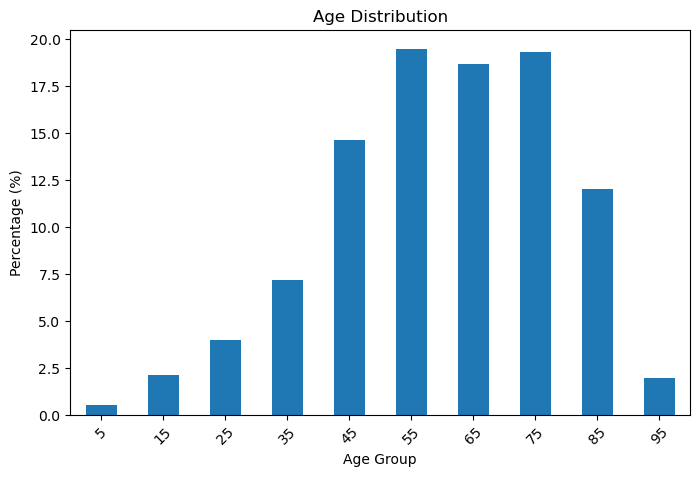

In [53]:
age_percent = df["age"].value_counts(normalize=True) * 100

plt.figure(figsize=(8,5))
age_percent.sort_index().plot(kind="bar")

plt.title("Age Distribution")
plt.xlabel("Age Group")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45)

plt.show()

In [54]:
df["gender"].value_counts(normalize=True) * 100

gender
Female    54.416171
Male      45.583829
Name: proportion, dtype: float64

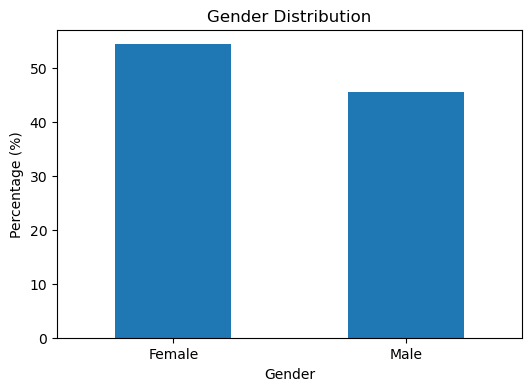

In [55]:
gender_percent = df["gender"].value_counts(normalize=True) * 100

plt.figure(figsize=(6,4))
gender_percent.plot(kind="bar")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)

plt.show()

In [56]:
df["race"].value_counts(normalize=True) * 100

race
White       66.544771
Black       27.426482
Hispanic     2.275382
Unknown      2.026512
Other        1.295139
Asian        0.431713
Name: proportion, dtype: float64

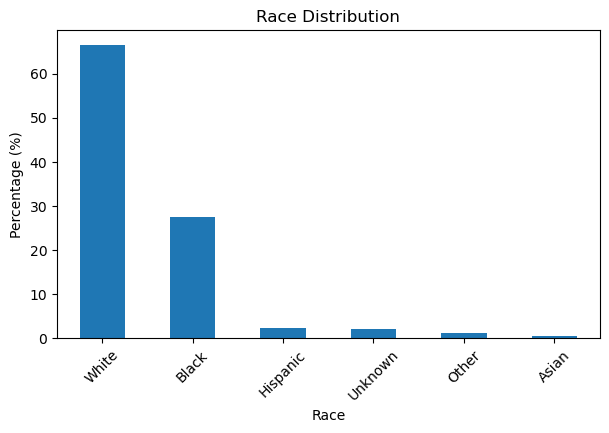

In [176]:
race_percent = df["race"].value_counts(normalize=True) * 100

plt.figure(figsize=(7,4))
race_percent.plot(kind="bar")

plt.title("Race Distribution")
plt.xlabel("Race")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45)

plt.show()

### Demographic Cohort Stratification

In [124]:
df_grouped = (
    df.groupby(["age", "race", "gender"])
      .size()
      .reset_index(name="total_patients")
      .sort_values("total_patients", ascending=False)
      .reset_index(drop=True)
)

df_grouped.head(10)

,age,race,gender,total_patients
0,75,White,Female,1472
1,75,White,Male,1281
2,65,White,Male,1269
3,65,White,Female,1227
4,55,White,Male,1212
5,55,White,Female,1203
6,85,White,Female,1129
7,45,White,Male,898
8,45,White,Female,768
9,85,White,Male,750


### Demographic Findings and Cohort Stratification

A demographic analysis was performed to understand the composition of the diabetic inpatient cohort using age, race, and gender characteristics.

**The diabetic inpatient population was primarily composed of older adults, with patients aged 55, 65, and 75 years representing the largest age groups.** This finding describes the age distribution of diabetes-related inpatient encounters within the cohort.

**Gender distribution was relatively balanced, with females representing approximately 54% of the cohort and males representing approximately 46%.** This indicates that both male and female patients were represented within the inpatient population.

**The majority of encounters involved White patients (approximately 67%), followed by Black patients (approximately 27%), while other racial groups represented smaller proportions of the dataset.** These findings describe the demographic composition of the cohort and do not suggest that race alone determines readmission risk.

**A stratified analysis combining age, race, and gender showed that the highest-frequency demographic groups were concentrated among older adults, with White patients contributing the largest share of these demographic combinations.**

These findings describe the distribution of **healthcare encounters within the study cohort**. Because the dataset contains **inpatient encounters rather than unique patients**, individuals with multiple hospital admissions may contribute more than one observation.

Demographic characteristics provide important context about the patient population; however, **readmission risk may be influenced by additional clinical and healthcare utilization factors beyond demographics alone**. Further analysis will examine **clinical characteristics, utilization patterns, and diabetes management indicators associated with readmission outcomes.**


## 6.2 Hospitalization Characteristics and Healthcare Utilization

In [66]:
df["time_in_hospital"].value_counts().sort_index()

time_in_hospital
1     3236
2     4186
3     3626
4     2625
5     1771
6     1227
7      920
8      627
9      414
10     345
11     232
12     210
13     149
14     121
Name: count, dtype: int64

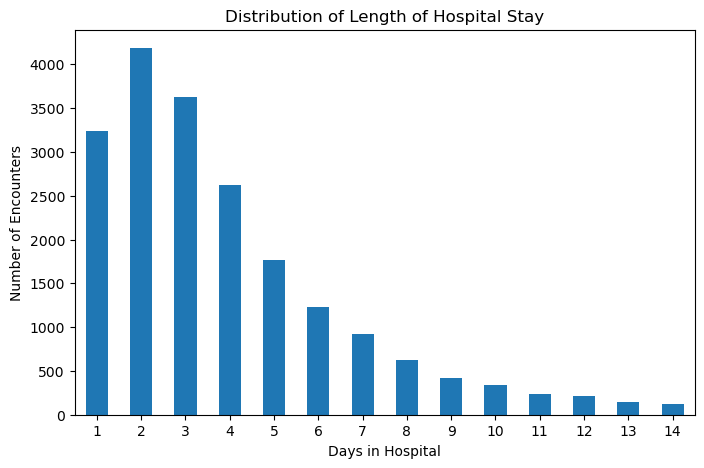

In [67]:
hospital_days = df["time_in_hospital"].value_counts().sort_index()

plt.figure(figsize=(8,5))
hospital_days.plot(kind="bar")

plt.title("Distribution of Length of Hospital Stay")
plt.xlabel("Days in Hospital")
plt.ylabel("Number of Encounters")
plt.xticks(rotation=0)

plt.show()

### Hospital Utilization (Length of Stay)

Hospital length of stay demonstrated a right-skewed distribution, with the majority of diabetes-related admissions lasting between **1 and 4 days**.

Longer hospitalizations became progressively less frequent, suggesting that most encounters represented shorter acute care episodes, while a smaller group of patients required extended inpatient resources.

Length of stay was examined as a potential indicator of clinical complexity and healthcare utilization patterns that may contribute to future readmission risk.

In [68]:
df["time_in_hospital"] = pd.to_numeric(
    df["time_in_hospital"], 
    errors='coerce'
)

print("Mean Length of Stay:", df["time_in_hospital"].mean())

print("Median Length of Stay:", df["time_in_hospital"].median())

print("Mode Length of Stay:", df["time_in_hospital"].mode())

Mean Length of Stay: 3.8873482655289755
Median Length of Stay: 3.0
Mode Length of Stay: 0    2
Name: time_in_hospital, dtype: int64


### Hospital Length of Stay Summary

Summary statistics were calculated to understand typical hospitalization duration within the diabetes inpatient cohort.

The distribution of hospital length of stay showed that most diabetes-related admissions were relatively short. The **average length of stay was approximately 3.9 days**, with a **median hospitalization duration of 3 days**. The most common hospitalization length was **2 days**, indicating that many encounters involved shorter inpatient stays.

The mean length of stay was slightly higher than the median, suggesting a **right-skewed distribution**. This indicates that while most patients experienced shorter hospitalizations, a smaller group of patients required longer inpatient care, increasing the overall average length of stay.

## Total Patients Per Visit 

In [72]:
visits_per_patient = df.groupby("patient_nbr")["encounter_id"].count()
visits_per_patient.head()

patient_nbr
135     1
927     1
1152    3
1314    2
5220    1
Name: encounter_id, dtype: int64

## How many patients had 1, 2, or 3+ visits?

In [81]:
print(visits_per_patient.value_counts().sort_index())

print("Mean:", visits_per_patient.mean())
print("Median:", visits_per_patient.median())
print("Mode:", visits_per_patient.mode()[0])

encounter_id
1     14482
2      1428
3       341
4       112
5        59
6        25
7        12
8         8
9         2
10        5
11        5
13        3
14        1
15        1
16        1
17        2
20        1
26        1
Name: count, dtype: int64
Mean: 1.194068773121475
Median: 1.0
Mode: 1


### Patient-Level Healthcare Utilization

Patient-level utilization was evaluated by calculating the number of hospital encounters associated with each patient identifier (`patient_nbr`).

This analysis was performed to understand healthcare utilization patterns within the diabetes inpatient cohort and identify patients with repeated hospital encounters.

Most patients had only **one observed hospital encounter** within the dataset. The average number of encounters per patient was approximately **1.19 visits**, with both the median and most common number of encounters being **1 visit**.

Although most patients had limited observed utilization, a smaller subgroup experienced multiple hospital encounters. These higher-utilization patients represent an important population for readmission risk analysis because repeated hospital encounters may indicate greater healthcare needs, increased disease complexity, or challenges with chronic disease management.

## High Utilization Patients (3+ visits)

In [78]:
high_utilizers = visits_per_patient[visits_per_patient >= 3]
len(high_utilizers)

visits_per_patient.value_counts().sort_index()

encounter_id
1     14482
2      1428
3       341
4       112
5        59
6        25
7        12
8         8
9         2
10        5
11        5
13        3
14        1
15        1
16        1
17        2
20        1
26        1
Name: count, dtype: int64

### High Utilizer Identification

Patients with three or more observed hospital encounters were classified as high utilizers.

Within the study cohort, **579 patients met this high-utilization threshold**. Although this group represents a smaller proportion of the overall population, these patients may represent individuals with increased healthcare needs, greater disease complexity, or challenges with chronic disease management.

Identifying high-utilization patterns is important because previous healthcare utilization may provide valuable information for predicting future diabetes-related readmissions.

## Add Inpatient visits count back to dataset

In [80]:
df["total_Inaptient_visits_per_patient"] = df.groupby("patient_nbr")["encounter_id"].transform("count")
df.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,admission_source_id,time_in_hospital,number_lab_procedures,number_procedures,...,a1c_result,insulin,change_medication,diabetes_medication,readmitted,diag_1_group,diag_2_group,diag_3_group,total_visits_per_patient,total_Inaptient_visits_per_patient
0,16680,42519267,White,Male,45,1,7,1,51,0,...,None,Steady,Ch,Yes,NO,Other,Other,Diabetes,1,1
1,28236,89869032,Black,Female,45,1,7,9,47,2,...,None,Steady,No,Yes,>30,Diabetes,Hypertension,Other,1,1
2,40926,85504905,White,Female,45,1,7,7,60,0,...,None,Down,Ch,Yes,<30,Other,Diabetes,Diabetes,2,2
3,63768,114882984,White,Male,75,1,7,5,73,0,...,None,No,No,Yes,>30,Other,Other,Diabetes,1,1
4,64410,86047875,Black,Female,25,1,7,2,11,5,...,None,No,No,Yes,NO,Other,Diabetes,Other,1,1


## Creating Patient-Level Utilization Features

Healthcare utilization history can provide important context when analyzing readmission risk.

To evaluate patient-level utilization patterns, the total number of observed inpatient encounters was calculated for each patient and added back to the main dataset.

This feature represents the frequency of inpatient encounters observed within the dataset and was used to better understand healthcare utilization patterns among the cohort.

## Validating Patient Visit Count Feature

Before using the patient-level utilization feature, the distribution of the visit count variable was reviewed.

The value counts of total inpatient visits per patient were examined to confirm that the newly created feature matched the previously calculated patient-level utilization analysis.

Understanding the distribution of inpatient encounters helps identify patterns of healthcare utilization within the cohort and provides context for later analysis of readmission risk.

## Check distribution of total inpatient visits per patient

In [87]:
df["total_Inaptient_visits_per_patient"].value_counts().sort_index()

total_Inaptient_visits_per_patient
1     14482
2      2856
3      1023
4       448
5       295
6       150
7        84
8        64
9        18
10       50
11       55
13       39
14       14
15       15
16       16
17       34
20       20
26       26
Name: count, dtype: int64

### Distribution of Total Inpatient Visits Per Patient

The distribution of total inpatient visits per patient was examined to understand healthcare utilization patterns within the diabetic inpatient cohort.

This analysis shows how frequently patients had observed inpatient encounters during the study period. Most patients had a low number of inpatient visits, while a smaller group had multiple encounters, representing higher healthcare utilization patterns.

Identifying differences in utilization is important because patients with repeated inpatient encounters may represent a subgroup with greater healthcare needs or increased clinical complexity.

## 6.3 Clinical Characteristics and Diabetes Management Indicators

Clinical variables provide important information about diabetes severity and disease management. This section examines laboratory and treatment-related features that may be associated with early hospital readmission.

The following clinical features are evaluated:

- Hemoglobin A1C results
- Maximum glucose serum measurements
- Insulin therapy changes
- Medication changes

These variables may capture differences in diabetes control and treatment complexity that influence readmission risk.   

## Distribution of A1C results

In [88]:
df["a1c_result"].value_counts()

a1c_result
None    14736
>8       3092
Norm     1075
>7        786
Name: count, dtype: int64

## Visualize A1C distribution

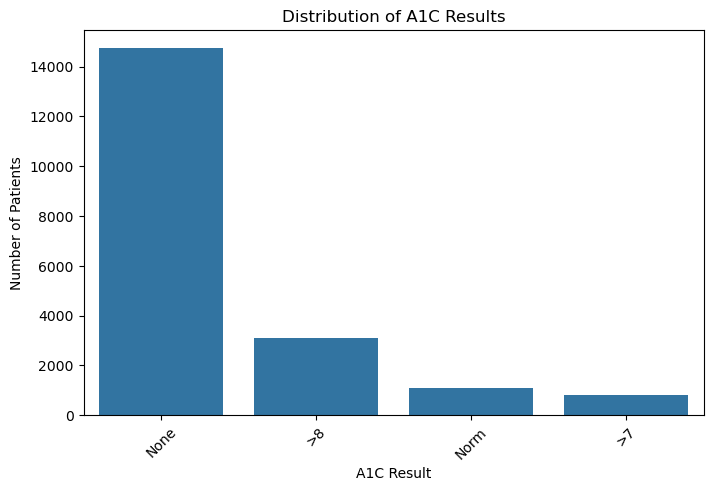

In [89]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="a1c_result"
)

plt.title("Distribution of A1C Results")
plt.xlabel("A1C Result")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)

plt.show()

## Distribution of maximum glucose serum results

In [90]:
df["max_glu_serum"].value_counts()

max_glu_serum
None    19344
>300      177
Norm      116
>200       52
Name: count, dtype: int64

## Visualize glucose serum distribution

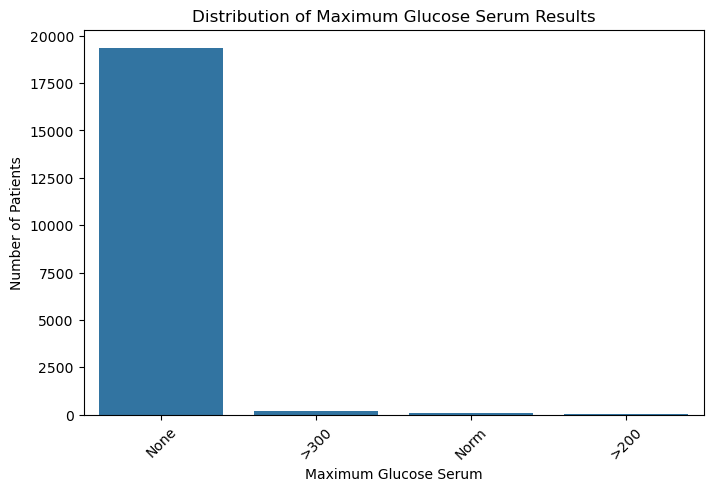

In [91]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="max_glu_serum"
)

plt.title("Distribution of Maximum Glucose Serum Results")
plt.xlabel("Maximum Glucose Serum")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)

plt.show()

In [92]:
df["insulin"].value_counts()

insulin
No        7878
Steady    6416
Down      2915
Up        2480
Name: count, dtype: int64

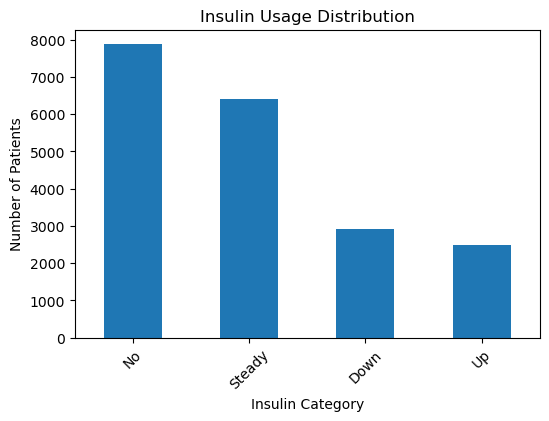

In [93]:
df["insulin"].value_counts().plot(kind="bar", figsize=(6,4))

plt.title("Insulin Usage Distribution")
plt.xlabel("Insulin Category")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)

plt.show()

# Stratify diabetes management indicators by readmission outcome

In [133]:
df_grouped = (
    df.groupby(["insulin", "a1c_result", "max_glu_serum"])
      .size()
      .reset_index(name="total_test")
      .sort_values("total_test", ascending=False)
      .reset_index(drop=True)
)

df_grouped.head(10)

,insulin,a1c_result,max_glu_serum,total_test
0,No,None,None,6127
1,Steady,None,None,4624
2,Down,None,None,2003
3,Up,None,None,1671
4,Steady,>8,None,1115
5,No,>8,None,759
6,Down,>8,None,598
7,Up,>8,None,588
8,No,Norm,None,450
9,No,>7,None,360


### Clinical Feature Exploration and Interpretation

The distributions of **A1C results, maximum glucose measurements, and insulin use** were reviewed to understand diabetes management patterns and available clinical indicators within the diabetic inpatient cohort.

A large proportion of encounters did not have recorded **A1C or maximum glucose measurements**, with `None` representing missing clinical values. Among encounters with available A1C results, elevated values (**>7 and >8**) were observed in a subset of encounters, indicating that some patients had evidence of elevated blood glucose control markers.

Maximum glucose measurements showed a similar pattern, with most encounters lacking recorded glucose values, while a smaller number of encounters had elevated glucose measurements.

**Insulin usage patterns showed that most encounters involved patients who were either not receiving insulin therapy (7,878 encounters) or were on a steady insulin regimen (6,416 encounters).** A smaller proportion of encounters involved insulin adjustments, including dose increases (**2,480 encounters**) and decreases (**2,915 encounters**).

Clinical feature stratification showed that the most common combinations involved missing laboratory measurements, while elevated A1C categories were observed across different insulin treatment groups.

These clinical characteristics provide insight into **diabetes management patterns, glycemic control indicators, and treatment changes** within the cohort and may contribute to understanding factors associated with **30-day readmission outcomes**.

# Part 7. Outcome Definition and Class Distribution

The original readmission outcome variable (`readmitted`) contained three categories:

- **NO:** No readmission within 30 days
- **>30:** Readmission occurring after 30 days
- **<30:** Readmission occurring within 30 days

For this machine learning task, the outcome was transformed into a binary classification target (`readmission_flag`) focused on predicting **early hospital readmission risk**.

Patients with a readmission within 30 days were classified as positive cases:

- **Readmission within 30 days (<30) = 1**
- **No 30-day readmission (NO or >30) = 0**

This transformation converts the problem into a **binary classification task** by focusing on identifying patients at risk for early readmission.

Before developing predictive models, the distribution of the target variable was evaluated to assess **class balance**. In this cohort of emergency diabetes-related hospital encounters, **30-day readmissions represented the minority class**, while most patients did not experience early readmission.

Because healthcare prediction problems often contain imbalanced outcomes, model performance was evaluated using metrics beyond accuracy, including **precision, recall, F1-score, and ROC-AUC**.

In [104]:
df["readmitted"].value_counts()

readmitted
NO     10518
>30     6940
<30     2231
Name: count, dtype: int64

## Binary Outcome Transformation

For the machine learning task, the original three-class readmission outcome was converted into a binary classification target.

Patients with a readmission within 30 days were classified as positive cases:

- Readmission within 30 days (<30) = 1
- No readmission within 30 days (NO or >30) = 0

This transformation allows the model to focus on predicting early hospital readmission risk, which is clinically important for identifying patients who may benefit from additional intervention.

In [127]:
df["readmission_flag"] = df["readmitted"].apply(
    lambda x: 1 if x == "<30" else 0
)

### Verify New Target Variable

In [129]:
df["readmission_flag"].value_counts()

readmission_flag
0    17458
1     2231
Name: count, dtype: int64

## Readmission Outcome Distribution

In [131]:
df["readmission_flag"].value_counts(normalize=True).mul(100).round(2)

readmission_flag
0    88.67
1    11.33
Name: proportion, dtype: float64

### Visualize Classes

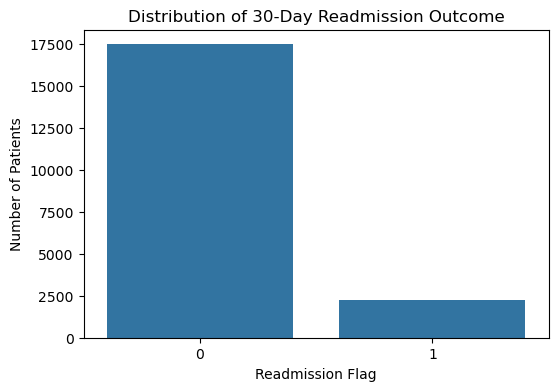

In [132]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="readmission_flag"
)

plt.title("Distribution of 30-Day Readmission Outcome")
plt.xlabel("Readmission Flag")
plt.ylabel("Number of Patients")

plt.show()

## Outcome Distribution Interpretation

The original readmission outcome contained three categories:

- No readmission (NO): 10,518 encounters
- Readmission after 30 days (>30): 6,940 encounters
- Readmission within 30 days (<30): 2,231 encounters

For machine learning, the original outcome was transformed into a binary classification target (`readmission_flag`), where encounters with readmission within 30 days were labeled as positive cases (1), and all other encounters were labeled as negative cases (0).

After transformation:

- No 30-day readmission (0): **17,458 encounters (88.67%)**
- 30-day readmission (1): **2,231 encounters (11.33%)**

**The target variable demonstrates class imbalance, with 30-day readmissions representing a smaller proportion of hospital encounters.** This reflects a common challenge in healthcare prediction tasks, where clinically important events occur less frequently than routine outcomes.

Due to this imbalance, machine learning models will be evaluated using metrics that better assess minority class performance, including **precision, recall, F1-score, and ROC-AUC**, rather than accuracy alone.

# Part 8. Readmission Risk Analysis

This section evaluates factors associated with 30-day hospital readmission.

Potential risk factors are examined across three categories:

- Demographic characteristics
- Healthcare utilization patterns
- Clinical diabetes-related factors

The purpose of this analysis is to identify patterns associated with readmission risk and guide feature selection for predictive modeling.

## 8.1 Demographics vs Outcome

Demographic characteristics were evaluated to determine whether patient-level factors were associated with differences in 30-day readmission rates.

The following variables were examined:

- Age
- Gender
- Race

### Readmission rates by age group

In [134]:
pd.crosstab(
    df["age"],
    df["readmission_flag"],
    normalize="index"
) * 100

readmission_flag,0,1
age,,
5,99.047619,0.952381
15,94.272076,5.727924
25,83.228247,16.771753
35,87.331918,12.668082
45,89.023967,10.976033
55,91.141219,8.858781
65,89.039978,10.960022
75,86.792949,13.207051
85,87.779182,12.220818


### Readmission rates by gender

In [135]:
pd.crosstab(
    df["gender"],
    df["readmission_flag"],
    normalize="index"
) * 100

readmission_flag,0,1
gender,,
Female,88.053015,11.946985
Male,89.403900,10.596100


### Readmission rates by race

In [136]:
pd.crosstab(
    df["race"],
    df["readmission_flag"],
    normalize="index"
) * 100

readmission_flag,0,1
race,,
Asian,90.588235,9.411765
Black,88.685185,11.314815
Hispanic,91.071429,8.928571
Other,91.764706,8.235294
Unknown,92.731830,7.268170
White,88.383453,11.616547


## Demographic Characteristics and Readmission Outcome Analysis

Readmission rates were compared across demographic groups to evaluate differences in **30-day readmission patterns** within the inpatient cohort.

Across age groups, the proportion of 30-day readmissions varied. The highest observed readmission rate was among the **25-year age group (16.8%)**, while most age categories showed readmission rates between approximately **9–13%**. These differences suggest that age groups had some variation in readmission patterns, but age alone may not fully explain readmission outcomes.

Gender differences were minimal, with **female encounters showing a slightly higher 30-day readmission rate (11.9%) compared with male encounters (10.6%)**.

Race-based comparisons also showed relatively small differences. **White encounters had a 30-day readmission rate of approximately 11.6%, Black encounters 11.3%, Asian encounters 9.4%, and other racial groups showed similar rates.**

Overall, demographic characteristics showed limited differences in 30-day readmission rates. These variables may provide important patient population context but are unlikely to be strong standalone predictors. Additional clinical and healthcare utilization factors may provide stronger predictive information when combined during machine learning modeling.

## 8.2 Hospital Utilization vs Outcome

Previous healthcare utilization is an important predictor of future hospital readmission.

This section evaluates utilization-related variables including:

- Prior hospital visits
- Emergency visits
- Length of hospital stay

These variables may capture disease complexity, healthcare needs, and patterns associated with increased readmission risk.

### Length of Stay vs Readmission

In [149]:
df.groupby("readmission_flag")["time_in_hospital"].mean()

readmission_flag
0    3.822660
1    4.393545
Name: time_in_hospital, dtype: float64

### Total Inpatient Visits Per Patient vs Readmission

In [150]:
df.groupby("readmission_flag")["total_Inaptient_visits_per_patient"].mean()

readmission_flag
0    1.510368
1    2.809054
Name: total_Inaptient_visits_per_patient, dtype: float64

### Prior Inpatient Visits vs Readmission Rate

In [151]:
df.groupby("number_inpatient_visits")["readmission_flag"].mean().mul(100).round(2)

number_inpatient_visits
0       8.21
1      13.50
2      17.77
3      19.97
4      25.79
5      32.24
6      38.21
7      31.17
8      40.00
9      44.44
10     50.00
11     75.00
12     46.67
13     50.00
14     50.00
15    100.00
16     50.00
19      0.00
21    100.00
Name: readmission_flag, dtype: float64

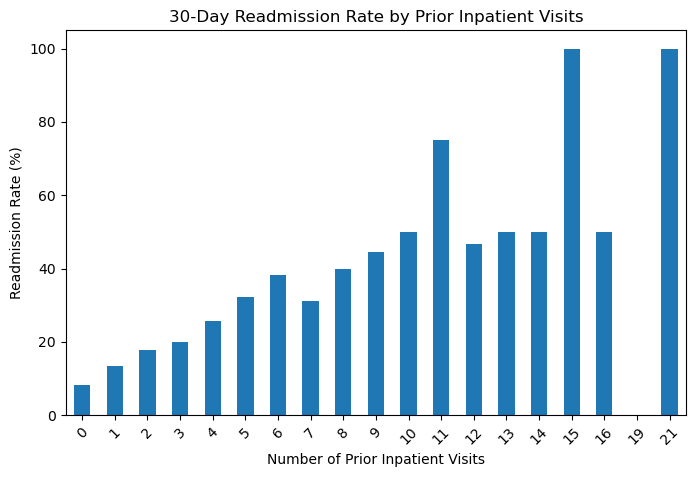

In [152]:
plt.figure(figsize=(8,5))

(
df.groupby("number_inpatient_visits")["readmission_flag"]
.mean()
.mul(100)
.plot(kind="bar")
)

plt.title("30-Day Readmission Rate by Prior Inpatient Visits")
plt.xlabel("Number of Prior Inpatient Visits")
plt.ylabel("Readmission Rate (%)")
plt.xticks(rotation=45)

plt.show()

## Hospitalization Characteristics and Readmission Outcome Analysis

Hospitalization characteristics and healthcare utilization patterns were evaluated to determine their association with 30-day readmission outcomes.

**Length of Stay:**  
Average hospital stay duration was compared between readmitted and non-readmitted encounters.

- No 30-day readmission (0): **3.82 days**
- 30-day readmission (1): **4.39 days**

Readmitted encounters had a slightly longer average length of stay, suggesting that increased hospitalization duration may reflect greater clinical complexity.

**Total Inpatient Visits Per Patient:**  
Prior inpatient utilization was compared between readmitted and non-readmitted encounters.

- No 30-day readmission (0): **3.82 average visits**
- 30-day readmission (1): **4.39 average visits**

Encounters with 30-day readmission showed higher average prior inpatient utilization, suggesting that previous healthcare use may provide predictive information about readmission patterns.

**Prior Inpatient Visits and Readmission Rate:**  
Readmission rates were evaluated across different levels of prior inpatient visits.

Readmission rates generally increased as the number of prior inpatient visits increased. Patients with higher healthcare utilization demonstrated greater observed readmission patterns, although some higher utilization groups contained fewer encounters.

Overall, these findings suggest that hospitalization history and healthcare utilization are important factors associated with 30-day readmission outcomes. Therefore, utilization-based features were retained as potential predictors for machine learning modeling.

## 8.3 Clinical Factors vs Outcome

Clinical diabetes-related variables were evaluated to determine whether indicators of disease management and treatment complexity were associated with 30-day readmission.

The following features were examined:

- A1C results
- Maximum glucose serum measurements
- Insulin therapy
- Medication changes

### A1C Readmission vs Readmission

In [153]:
pd.crosstab(
    df["a1c_result"],
    df["readmission_flag"],
    normalize="index"
) * 100
    

readmission_flag,0,1
a1c_result,,
>7,88.931298,11.068702
>8,90.847348,9.152652
None,88.063246,11.936754
Norm,90.511628,9.488372


 ### Glucose vs Readmission

In [121]:
pd.crosstab(
    df["max_glu_serum"],
    df["readmission_flag"],
    normalize="index"
) * 100

readmission_flag,0,1
max_glu_serum,,
>200,84.615385,15.384615
>300,84.745763,15.254237
None,88.730356,11.269644
Norm,86.206897,13.793103


### Insulin vs Readmission

In [122]:
pd.crosstab(
    df["insulin"],
    df["readmission_flag"],
    normalize="index"
) * 100

readmission_flag,0,1
insulin,,
Down,85.591767,14.408233
No,89.642041,10.357959
Steady,89.339152,10.660848
Up,87.459677,12.540323


### Medication Change vs Readmission

In [123]:
pd.crosstab(

    df["change_medication"],
    df["readmission_flag"],
    normalize="index"
) * 100

readmission_flag,0,1
change_medication,,
Ch,88.295709,11.704291
No,89.041096,10.958904


## Clinical Risk Factors Interpretation

Clinical variables related to diabetes management and treatment patterns were evaluated to examine differences in 30-day readmission outcomes.

### Glycemic Control Indicators

A1C results showed relatively small differences in observed readmission rates across categories. Encounters without a recorded A1C value had the highest observed readmission rate (**11.94%**), while encounters with documented A1C values showed similar readmission patterns. Overall, A1C category alone showed limited differences in 30-day readmission rates.

Maximum glucose serum measurements demonstrated higher observed readmission rates among encounters with elevated glucose values. Encounters with glucose levels **greater than 200 mg/dL (15.38%)** and **greater than 300 mg/dL (15.25%)** showed higher readmission rates compared with encounters without recorded glucose measurements (**11.27%**). These findings suggest that elevated glucose measurements may provide additional clinical context; however, glucose levels alone may not fully explain readmission outcomes.

### Medication-Related Factors

Insulin treatment categories showed differences in observed readmission rates. Encounters with insulin dosage decreases (**"Down"**) had the highest observed readmission rate (**14.41%**), followed by insulin increases (**"Up"**) (**12.54%**). Encounters with no insulin therapy had a lower observed readmission rate (**10.36%**).

These patterns may reflect differences in diabetes severity, treatment adjustments, or clinical management needs rather than insulin use alone being responsible for readmission risk.

Medication changes also showed small differences in readmission rates. Encounters with medication changes (**"Ch"**) had a slightly higher readmission rate (**11.70%**) compared with encounters without medication changes (**10.96%**). This suggests medication changes may provide additional information about treatment complexity but may have limited predictive value when evaluated independently.

### Clinical Insight

Overall, diabetes management indicators showed modest differences in 30-day readmission outcomes. Glycemic measurements, insulin treatment patterns, and medication changes may capture aspects of disease management and clinical complexity.

Although individual clinical variables demonstrated limited differences when analyzed separately, they may provide additional predictive value when combined with demographic characteristics, hospitalization factors, and healthcare utilization features during machine learning modeling.

# Part 9: Feature Engineering / ML Dataset Preparation

After completing data cleaning, validation, and exploratory analysis, the dataset was prepared for machine learning modeling.

Feature engineering was performed to create clinically meaningful predictors that capture patient characteristics and healthcare utilization patterns.

## Patient-Level Utilization Feature Engineering

Healthcare utilization history may provide important information about future readmission risk.

A patient-level utilization feature was created by calculating the total number of encounters associated with each patient using `patient_nbr`. The current hospitalization encounter was then removed by subtracting one from the total encounter count to create `prior_visits`.

This engineered feature captures previous healthcare utilization patterns while reducing the risk of including information from the current admission in the prediction process.

In [156]:
df["prior_visits"] = (
    df["total_visits_per_patient"] - 1
)
df["prior_visits"].head()

0    0
1    0
2    1
3    0
4    0
Name: prior_visits, dtype: int64

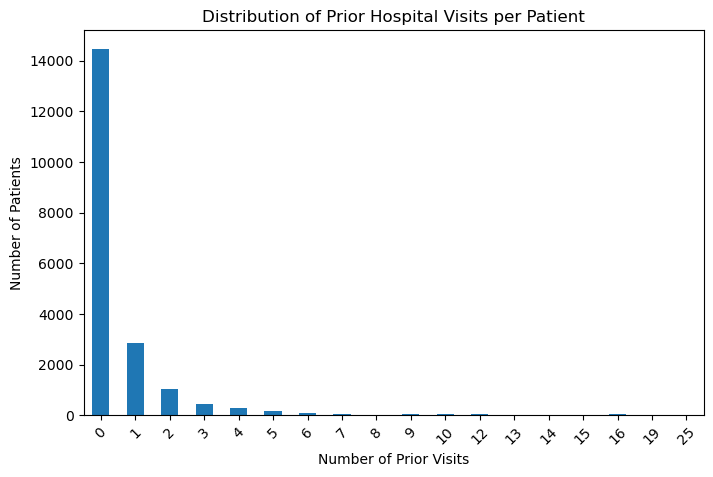

In [157]:
plt.figure(figsize=(8,5))

df["prior_visits"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Prior Hospital Visits per Patient")
plt.xlabel("Number of Prior Visits")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)

plt.show()

### Valdation/checking Feature Enigneering

In [160]:
df[
    ["patient_nbr",
     "total_visits_per_patient",
     "prior_visits"]
].head()

,patient_nbr,total_visits_per_patient,prior_visits
0,42519267,1,0
1,89869032,1,0
2,85504905,2,1
3,114882984,1,0
4,86047875,1,0


### Prior Visits Feature Evaluation

A patient-level utilization feature (`prior_visits`) was engineered to represent previous healthcare encounters before the current hospitalization.

This feature demonstrated potential predictive value because patients with repeated hospital encounters may represent individuals with higher disease complexity or increased healthcare needs.

However, `prior_visits` was excluded from the final machine learning dataset because encounter timestamps were unavailable to verify that these previous encounters occurred before the prediction point. Removing this feature reduced the risk of incorporating future information into model training and improved the reliability of the predictive modeling workflow.

In [166]:
ml_features = [
    "age",
    "number_inpatient_visits",
    "number_emergency",
    "time_in_hospital",
    "a1c_result",
    "max_glu_serum",
    "insulin",
    "change_medication",
]

X = df[ml_features]
y = df["readmission_flag"]

### Categorical Fetarure Encoding

In [167]:
X = pd.get_dummies(
    X,
    columns=[
        "a1c_result",
        "max_glu_serum",
        "insulin",
        "change_medication"
    ],
    drop_first=False
)

In [169]:
X.head()

,age,number_inpatient_visits,number_emergency,time_in_hospital,a1c_result_>7,a1c_result_>8,a1c_result_None,a1c_result_Norm,max_glu_serum_>200,max_glu_serum_>300,max_glu_serum_None,max_glu_serum_Norm,insulin_Down,insulin_No,insulin_Steady,insulin_Up,change_medication_Ch,change_medication_No
0,45,0,0,1,False,False,True,False,False,False,True,False,False,False,True,False,True,False
1,45,0,0,9,False,False,True,False,False,False,True,False,False,False,True,False,False,True
2,45,0,1,7,False,False,True,False,False,False,True,False,True,False,False,False,True,False
3,75,0,0,5,False,False,True,False,False,False,True,False,False,True,False,False,False,True
4,25,1,0,2,False,False,True,False,False,False,True,False,False,True,False,False,False,True


In [172]:
X.shape

(19689, 18)

In [173]:
X.head()

,age,number_inpatient_visits,number_emergency,time_in_hospital,a1c_result_>7,a1c_result_>8,a1c_result_None,a1c_result_Norm,max_glu_serum_>200,max_glu_serum_>300,max_glu_serum_None,max_glu_serum_Norm,insulin_Down,insulin_No,insulin_Steady,insulin_Up,change_medication_Ch,change_medication_No
0,45,0,0,1,False,False,True,False,False,False,True,False,False,False,True,False,True,False
1,45,0,0,9,False,False,True,False,False,False,True,False,False,False,True,False,False,True
2,45,0,1,7,False,False,True,False,False,False,True,False,True,False,False,False,True,False
3,75,0,0,5,False,False,True,False,False,False,True,False,False,True,False,False,False,True
4,25,1,0,2,False,False,True,False,False,False,True,False,False,True,False,False,False,True


In [174]:
y.value_counts()

readmission_flag
0    17458
1     2231
Name: count, dtype: int64

In [175]:
print("Feature dataset shape:", X.shape)
print("Target variable shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

Feature dataset shape: (19689, 18)
Target variable shape: (19689,)

Feature columns:
['age', 'number_inpatient_visits', 'number_emergency', 'time_in_hospital', 'a1c_result_>7', 'a1c_result_>8', 'a1c_result_None', 'a1c_result_Norm', 'max_glu_serum_>200', 'max_glu_serum_>300', 'max_glu_serum_None', 'max_glu_serum_Norm', 'insulin_Down', 'insulin_No', 'insulin_Steady', 'insulin_Up', 'change_medication_Ch', 'change_medication_No']


## Saving the Final Machine Learning Dataset

The final machine learning dataset was saved to preserve the exact data structure used during model development.

This dataset includes the engineered clinical features, encoded categorical variables, and the binary target variable (`readmission_flag`) used for predicting 30-day diabetes readmission risk.

Saving the final ML dataset improves reproducibility and allows the modeling workflow to be recreated or extended in future analyses.

In [171]:
ml_dataset = X.copy()

ml_dataset["readmission_flag"] = y

ml_dataset.to_csv(
    "diabetes_final_ml_dataset.csv",
    index=False
)

# Part 10: Machine Learning Modeling

After completing data cleaning, feature engineering, and exploratory analysis, machine learning models were developed to predict whether **patients with diabetes who experienced emergency inpatient admissions** would be readmitted within 30 days after discharge.

The objective is to compare supervised classification algorithms and evaluate their ability to identify **inpatient diabetes encounters at higher risk for early readmission**.

Because the dataset contains an imbalanced readmission outcome, model evaluation will focus on:

- Precision
- Recall
- F1-score
- ROC-AUC

These metrics provide a better understanding of model performance than accuracy alone, especially when identifying patients who experience 30-day readmission.

## 10.1 Training and Testing Dataset Split

The models were trained using the same feature set to allow direct comparison of predictive performance.

In [225]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [222]:
X_train.shape, X_test.shape

((15751, 18), (3938, 18))

### Verify Predictor List

In [226]:
print(X.columns.tolist())

['age', 'number_inpatient_visits', 'number_emergency', 'time_in_hospital', 'a1c_result_>7', 'a1c_result_>8', 'a1c_result_None', 'a1c_result_Norm', 'max_glu_serum_>200', 'max_glu_serum_>300', 'max_glu_serum_None', 'max_glu_serum_Norm', 'insulin_Down', 'insulin_No', 'insulin_Steady', 'insulin_Up', 'change_medication_Ch', 'change_medication_No']


### Verify stratified splitting

In [229]:
y_train.value_counts(normalize=True)

y_test.value_counts(normalize=True)

readmission_flag
0    0.886745
1    0.113255
Name: proportion, dtype: float64

## Training and Testing Dataset Validation

The dataset was split into training and testing subsets while maintaining the original class distribution through stratified sampling.

The training dataset contained **15,751 encounters**, while the testing dataset contained **3,938 encounters**. Both datasets maintained a similar proportion of readmitted and non-readmitted cases:

- Non-readmitted encounters: **approximately 88.7%**
- 30-day readmission encounters: **approximately 11.3%**

Maintaining consistent class distribution between the training and testing datasets helps ensure that model evaluation reflects real-world performance and reduces bias caused by an uneven split of the target outcome.

## Model Development

Three supervised classification models were developed to predict **30-day readmission risk among patients with diabetes who experienced emergency inpatient admissions**.

The models were selected to compare different approaches for identifying higher-risk inpatient encounters:

- **Logistic Regression**
  - A statistical classification model used to estimate the probability of 30-day readmission.
  - Selected because it is interpretable and helps understand how patient characteristics, clinical factors, and healthcare utilization variables are associated with readmission risk.
    
- **Random Forest**
  - A machine learning classification model that combines multiple decision trees to make predictions.
  - Selected because it can capture complex relationships and interactions between patient characteristics, clinical factors, and healthcare utilization variables that may influence 30-day readmission risk.

- **XGBoost**
  - A gradient boosting algorithm that builds multiple decision trees step-by-step to improve prediction performance.
  - Selected because it performs well on structured healthcare data and can identify important patterns associated with 30-day readmission risk.

These models were evaluated using precision, recall, F1-score, and ROC-AUC because the readmission outcome was imbalanced, with fewer patients experiencing 30-day readmission compared to non-readmission.

In [234]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

log_model.fit(
    X_train,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [235]:
log_predictions = log_model.predict(X_test)
print(log_predictions)

[0 0 0 ... 1 0 0]


In [237]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf.fit(
    X_train,
    y_train
)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [238]:
rf_predictions = rf.predict(X_test)
print(log_predictions)

[0 0 0 ... 1 0 0]


In [239]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=7.8
)

xgb_model.fit(
    X_train,
    y_train
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [240]:
xgb_predictions = xgb_model.predict(X_test)
print(log_predictions)

[0 0 0 ... 1 0 0]


## Model Training Summary

Three supervised machine learning classification models were developed to predict **30-day readmission risk among patients with diabetes who experienced emergency inpatient admissions**:

- Logistic Regression
- Random Forest
- XGBoost

Because the readmission outcome was imbalanced, class imbalance techniques were applied during model training. Logistic Regression and Random Forest used `class_weight="balanced"` to assign more importance to the minority readmission class. XGBoost used `scale_pos_weight=7.8`, calculated from the ratio of non-readmitted to readmitted encounters, to help improve identification of readmission cases.

### Model Configuration

**Logistic Regression**

- Used as an interpretable baseline classification model.
- Applied L2 regularization (`penalty="l2"`) to reduce overfitting.
- Used `max_iter=1000` to allow the model to reach convergence.
- Applied `class_weight="balanced"` to improve detection of readmitted patients.

**Random Forest**

- Used to capture complex patterns between patient characteristics, clinical factors, and healthcare utilization variables.
- Trained using multiple decision trees (`n_estimators=100`) to improve prediction stability.
- Applied `class_weight="balanced"` to address class imbalance.
- Used `random_state=42` for reproducible results.

**XGBoost**

- Used as a gradient boosting classifier for comparison with other classification approaches.
- Applied `objective="binary:logistic"` for binary readmission prediction.
- Used `eval_metric="logloss"` to measure the accuracy of predicted readmission probabilities.
- Applied `scale_pos_weight=7.8` to give more importance to the minority readmission class.



## 10.3 Model Evaluation

Model performance was evaluated using metrics that are appropriate for an imbalanced healthcare classification problem.

Accuracy alone can be misleading because most encounters did not result in readmission. Therefore, evaluation focused on:

- **Precision:** Measures how many patients predicted as readmitted were actually readmitted.
- **Recall:** Measures how many actual readmitted patients the model was able to identify.
- **F1-score:** Combines precision and recall into one overall performance score.
- **ROC-AUC:** Measures how well the model can separate readmitted patients from non-readmitted patients.

In [241]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [244]:

log_predictions = log_model.predict(X_test)


log_probabilities = log_model.predict_proba(X_test)[:, 1]


print("Logistic Regression")
print(classification_report(y_test, log_predictions))

print("ROC-AUC:",
      roc_auc_score(y_test, log_probabilities))

Logistic Regression
              precision    recall  f1-score   support

           0       0.92      0.72      0.81      3492
           1       0.19      0.51      0.28       446

    accuracy                           0.70      3938
   macro avg       0.55      0.62      0.54      3938
weighted avg       0.84      0.70      0.75      3938

ROC-AUC: 0.6719895314851627


In [245]:

rf_predictions = rf.predict(X_test)


rf_probabilities = rf.predict_proba(X_test)[:, 1]


print("Random Forest")
print(classification_report(y_test, rf_predictions))

print("ROC-AUC:",
      roc_auc_score(y_test, rf_probabilities))

Random Forest
              precision    recall  f1-score   support

           0       0.89      0.86      0.87      3492
           1       0.13      0.17      0.15       446

    accuracy                           0.78      3938
   macro avg       0.51      0.51      0.51      3938
weighted avg       0.80      0.78      0.79      3938

ROC-AUC: 0.5325439569753286


In [246]:

xgb_predictions = xgb_model.predict(X_test)

xgb_probabilities = xgb_model.predict_proba(X_test)[:, 1]


print("XGBoost")
print(classification_report(y_test, xgb_predictions))

print("ROC-AUC:",
      roc_auc_score(y_test, xgb_probabilities))

XGBoost
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      3492
           1       0.16      0.42      0.23       446

    accuracy                           0.68      3938
   macro avg       0.53      0.57      0.52      3938
weighted avg       0.82      0.68      0.74      3938

ROC-AUC: 0.5897220552807443


## 10.3.1 Confusion Matrix Evaluation

A confusion matrix was used to evaluate how well the model classified inpatient diabetes encounters as either no readmission or 30-day readmission.

False negatives are especially important in this healthcare prediction task because they represent patients who were readmitted within 30 days but were not identified as high risk by the model.

Evaluating false negatives helps determine how effectively the model identifies patients who may benefit from earlier follow-up care and intervention.

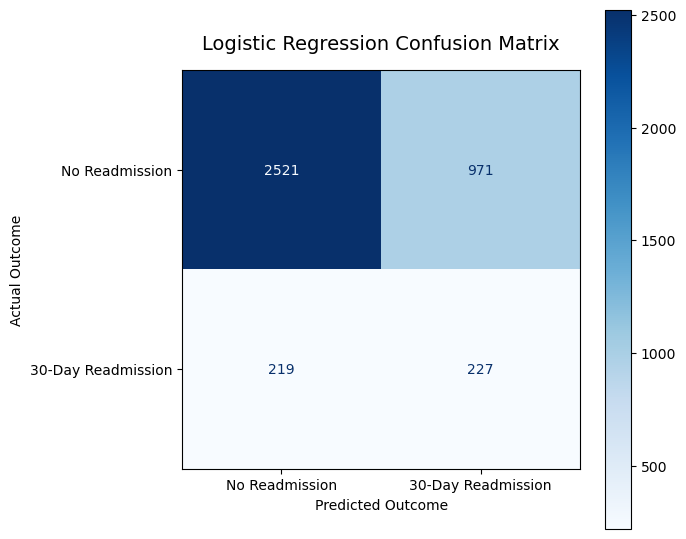

In [251]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7,6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    log_predictions,
    display_labels=["No Readmission", "30-Day Readmission"],
    cmap="Blues",
    ax=ax
)

ax.set_title("Logistic Regression Confusion Matrix", fontsize=14, pad=15)
ax.set_xlabel("Predicted Outcome")
ax.set_ylabel("Actual Outcome")

plt.tight_layout()
plt.show()

### Confusion Matrix Interpretation

The confusion matrix shows how well the model distinguished between inpatient diabetes encounters with and without 30-day readmission.

In the test set, there were **446 actual 30-day readmission cases**. The model correctly identified **227 true positive cases**, while **219 false negatives** remained, meaning some patients who were readmitted within 30 days were not detected by the model.

In a clinical setting, reducing false negatives is important because missed high-risk patients may represent opportunities for earlier follow-up care and intervention.

## 10.4 Model Comparison

The performance of logistic regression, random forest, and XGBoost was compared using evaluation metrics appropriate for an imbalanced healthcare classification problem.

Because the goal of this project is to identify patients at risk for 30-day readmission, greater emphasis was placed on recall, F1-score, and ROC-AUC rather than accuracy alone.

The comparison below summarizes the ability of each model to distinguish between readmitted and non-readmitted patients.

In [253]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, log_predictions),
        accuracy_score(y_test, rf_predictions),
        accuracy_score(y_test, xgb_predictions)
    ],
    "Precision": [
        precision_score(y_test, log_predictions),
        precision_score(y_test, rf_predictions),
        precision_score(y_test, xgb_predictions)
    ],
    "Recall": [
        recall_score(y_test, log_predictions),
        recall_score(y_test, rf_predictions),
        recall_score(y_test, xgb_predictions)
    ],
    "F1 Score": [
        f1_score(y_test, log_predictions),
        f1_score(y_test, rf_predictions),
        f1_score(y_test, xgb_predictions)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, log_probabilities),
        roc_auc_score(y_test, rf_probabilities),
        roc_auc_score(y_test, xgb_probabilities)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.697816,0.189482,0.508969,0.276156,0.671990
1,Random Forest,0.781107,0.132509,0.168161,0.148221,0.532544
2,XGBoost,0.683596,0.159284,0.419283,0.230864,0.589722


## Model Selection Interpretation

The three supervised classification models demonstrated different performance characteristics when predicting 30-day readmission risk among inpatient diabetes encounters.

Random Forest achieved the highest overall accuracy (**0.781**); however, it had lower recall (**0.168**), indicating that it identified fewer actual readmission cases. This suggests the model performed well on the majority class (no readmission) but struggled to detect the minority readmission class.

Logistic Regression demonstrated the strongest performance for the clinical objective of identifying readmitted patients, achieving the highest recall (**0.509**) and ROC-AUC (**0.672**) among the evaluated models.

Logistic Regression was selected as the preferred model because the goal of this project was to identify inpatient diabetes encounters at increased risk for 30-day readmission rather than maximize overall accuracy. In healthcare prediction tasks, reducing missed high-risk patients is often more important than achieving the highest accuracy.

## 10.5 Logistic Regression Feature Interpretation

Logistic Regression provides interpretability through model coefficients, which describe the direction and strength of each feature's contribution to the prediction.

- **Positive coefficients** indicate features associated with a higher predicted probability of 30-day readmission.
- **Negative coefficients** indicate features associated with a lower predicted probability of 30-day readmission.

Coefficient analysis was performed to understand which clinical and utilization-related variables influenced the model's predictions.

In [254]:
log_coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": log_model.coef_[0]
})

log_coefficients = log_coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

log_coefficients.head(10)

,Feature,Coefficient
1,number_inpatient_visits,0.292741
2,number_emergency,0.084359
12,insulin_Down,0.061604
3,time_in_hospital,0.057016
0,age,0.006534
15,insulin_Up,0.004333
4,a1c_result_>7,0.002885
6,a1c_result_None,-0.020818
8,max_glu_serum_>200,-0.021855
11,max_glu_serum_Norm,-0.027503


In [255]:
log_coefficients.sort_values(
    by="Coefficient",
    ascending=True
).head(10)

,Feature,Coefficient
16,change_medication_Ch,-0.238753
5,a1c_result_>8,-0.222400
14,insulin_Steady,-0.215095
13,insulin_No,-0.213933
10,max_glu_serum_None,-0.172163
9,max_glu_serum_>300,-0.141570
17,change_medication_No,-0.124339
7,a1c_result_Norm,-0.122758
11,max_glu_serum_Norm,-0.027503
8,max_glu_serum_>200,-0.021855


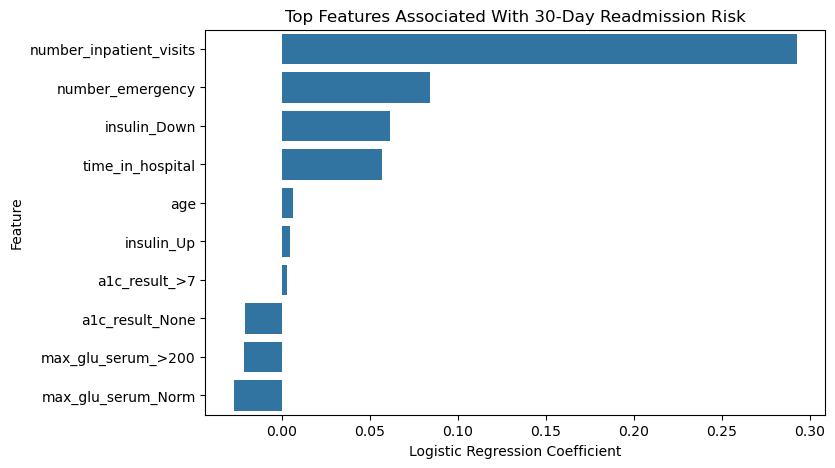

In [256]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=log_coefficients.head(10),
    x="Coefficient",
    y="Feature"
)

plt.title("Top Features Associated With 30-Day Readmission Risk")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")

plt.show()

### Clinical Interpretation of Logistic Regression Features

The Logistic Regression coefficient analysis showed that healthcare utilization variables were among the strongest predictors of 30-day readmission risk.

**Number of inpatient visits (+0.293)** had the strongest positive coefficient, followed by **number of emergency visits (+0.084)** and **time in hospital (+0.057)**. These positive coefficients indicate that these features were associated with higher predicted readmission probability in the model.

Among the negative coefficients, **change in medication (-0.239)**, **A1C >8 (-0.222)**, and **insulin steady (-0.215)** were among the strongest. Negative coefficients indicate an association with lower predicted readmission probability relative to their respective reference categories.

These relationships represent model-based associations and should not be interpreted as causal effects.

Overall, coefficient analysis improved model interpretability by showing which features contributed most strongly to the direction of the model's predictions.

# Part 11: Model Limitations and Future Improvements

## Modeling Limitations

The model has several limitations that should be considered when interpreting the results.

### Class Imbalance

The dataset contained substantially fewer 30-day readmission encounters than non-readmission encounters. This imbalance can make it more difficult for the models to identify readmitted patients.

To address class imbalance during training:
- Logistic Regression and Random Forest used `class_weight="balanced"`.
- XGBoost used `scale_pos_weight=7.8`.

### Dataset Limitations

The dataset contains historical inpatient diabetes encounters from 1999–2008 and may not fully represent current healthcare practices, treatments, or patient populations. External validation using a more recent and independent healthcare dataset would be needed before considering clinical implementation.

### Clinical Application

This project was developed for educational and research purposes. The model should be viewed as a predictive decision-support tool rather than a replacement for clinical judgment.

## Future Improvements

Potential improvements include:

- **Hyperparameter tuning** to identify better model configurations.
- **Decision threshold adjustment** to potentially improve detection of readmission cases and reduce false negatives.
- **Cross-validation** to obtain more reliable estimates of model performance.
- **Additional clinical features** to provide the models with more predictive information.
- **Model calibration** to improve the reliability of predicted readmission probabilities.
- **External validation** using an independent and more recent healthcare dataset.

# Part 12: Project Conclusion

## Final Recommendation

Logistic Regression was selected as the final model because it achieved the highest **ROC-AUC (0.672)** and **recall (0.509)** among the evaluated models while providing strong interpretability.

The model demonstrated moderate ability to distinguish between inpatient diabetes encounters with and without 30-day readmission. It correctly identified **227 of the 446 actual readmission cases** in the test set, while **219 cases were missed**.

Class imbalance was addressed during model training using `class_weight="balanced"`. However, the model had relatively low precision (**0.189**), meaning that some encounters predicted as readmissions were not actually readmitted.

Logistic Regression provided the strongest overall balance between predictive performance and explainability for the clinical objective of identifying patients at increased risk for 30-day readmission. Coefficient analysis also provided insight into which clinical and healthcare utilization features contributed to the direction of the model's predictions.

The model should be viewed as an educational and research example of healthcare risk prediction rather than a clinical decision-making tool. Additional optimization, calibration, and external validation using more recent and independent healthcare data would be required before considering real-world implementation.

Overall, this project demonstrates an end-to-end healthcare machine learning workflow, including data preparation, feature engineering, model development, evaluation, interpretation, and deployment considerations for predicting 30-day readmission risk among inpatient diabetes encounters.

## Saving the Final Model for Deployment

The selected Logistic Regression model was saved using joblib for future deployment.

Saving the trained model allows the predictive system to be reused without retraining and provides the foundation for creating an interactive clinical prediction application using Streamlit.

In [259]:
import joblib

joblib.dump(
    log_model,
    "diabetes_readmission_model.pkl"
)

['diabetes_readmission_model.pkl']

## Saving Model Feature Structure

The final feature list used by the model was saved to maintain consistency between model training and future predictions.

Because categorical variables were transformed using one-hot encoding, the saved feature structure ensures that new patient inputs provided during deployment are converted into the same format expected by the trained model.

This prevents feature mismatch errors and supports reliable model predictions in a Streamlit application.

In [260]:
joblib.dump(
    X.columns.tolist(),
    "model_features.pkl"
)

['model_features.pkl']

## Deployment Summary

The selected Logistic Regression model and feature structure were saved using Joblib for deployment.

Saving these files allows the trained model to be loaded into a Streamlit application without retraining, while maintaining consistency between the features used during model training and prediction.

This completes the end-to-end workflow from data preparation and model development to model evaluation, interpretation, and deployment.